## Import libraries

In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os, sys
from IPython.display import Image
from datetime import datetime

project_root = Path.cwd().parent.parent
sys.path.append(str(project_root))
os.chdir(project_root)


from fmu2ml.analysis.nonlinear_characterization.analyzers import (
    NonlinearAnalyzer,
    ThresholdDetector
)
from fmu2ml.analysis.nonlinear_characterization.visualizers.residual_visualizer import (
    create_residual_summary_plot
)
from fmu2ml.analysis.nonlinear_characterization.visualizers.threshold_visualizer import (
    create_threshold_summary_plot
)
from fmu2ml.analysis.nonlinear_characterization.visualizers import *
from fmu2ml.analysis.input_output_relations.analyzers import DataGenerator
from raps.config import ConfigManager

sns.set_style("whitegrid")
%matplotlib inline

## Define Parameters

In [2]:

# Configuration
SYSTEM_NAME = 'summit'

SAMPLES_PER_HOUR = 60
TOTAL_TIMESTEPS = 7200
MAX_POLYNOMIAL_DEGREE = 5
MAX_BREAKPOINTS = 3
OUTPUT_DIR = f'../results/{SYSTEM_NAME}/data_analysis/nonlinear_characterization'
DATA_DIR = f'../results/{SYSTEM_NAME}/data_analysis/direct_effect_analysis'

# Load Configuration and Initialize
config = ConfigManager(system_name=SYSTEM_NAME).get_config()
num_cdus = config.get('NUM_CDUS', 49)

print(f"Number of CDUs: {num_cdus}")
print(f"Configuration loaded for {SYSTEM_NAME}")

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Input ranges
INPUT_RANGES = {
    'Q_flow': (config.get('MIN_POWER'), config.get('MAX_POWER')),    # kW
    'T_Air': (288.15, 308.15),   # K
    'T_ext': (283.15, 313.15)    # K
}


# Parallel settings
N_WORKERS = 48
THREADS_PER_WORKER = 1
MEMORY_LIMIT = '64GB'

# Key outputs
KEY_OUTPUTS = ['T_prim_r_C', 'W_flow_CDUP_kW', 'V_flow_prim_GPM']

print(f"System: {SYSTEM_NAME}")
print(f"Max polynomial degree: {MAX_POLYNOMIAL_DEGREE}")
print(f"Max breakpoints: {MAX_BREAKPOINTS}")
print(f"Output dir: {OUTPUT_DIR}")


Number of CDUs: 257
Configuration loaded for summit
System: summit
Max polynomial degree: 5
Max breakpoints: 3
Output dir: ../results/summit/data_analysis/nonlinear_characterization


In [3]:

# Initialize Components
config_for_components = {k: v for k, v in config.items() 
                        if k not in ['system_name', 'max_polynomial_degree', 'max_breakpoints']}

# Data generator
data_generator = DataGenerator(
    system_name=SYSTEM_NAME,
    n_workers=N_WORKERS,
    **config_for_components
)

# Nonlinear analyzer
nonlinear_analyzer = NonlinearAnalyzer(
    system_name=SYSTEM_NAME,
    n_workers=N_WORKERS,
    threads_per_worker=THREADS_PER_WORKER,
    memory_limit=MEMORY_LIMIT,
    max_polynomial_degree=MAX_POLYNOMIAL_DEGREE,
    **config_for_components
)

# Threshold detector
threshold_detector = ThresholdDetector(
    system_name=SYSTEM_NAME,
    n_workers=N_WORKERS,
    threads_per_worker=THREADS_PER_WORKER,
    memory_limit=MEMORY_LIMIT,
    max_breakpoints=MAX_BREAKPOINTS,
    **config_for_components
)

print("Components initialized")


2026-02-06 17:34:08 - fmu2ml.analysis.input_output_relations.analyzers.data_generator - INFO - DataGenerator initialized for system: summit
2026-02-06 17:34:08 - fmu2ml.analysis.input_output_relations.analyzers.data_generator - INFO - Number of CDUs: 257
2026-02-06 17:34:08 - fmu2ml.analysis.nonlinear_characterization.analyzers.nonlinear_analyzer - INFO - NonlinearAnalyzer initialized for system: summit
2026-02-06 17:34:08 - fmu2ml.analysis.nonlinear_characterization.analyzers.nonlinear_analyzer - INFO - Number of CDUs: 257
2026-02-06 17:34:08 - fmu2ml.analysis.nonlinear_characterization.analyzers.nonlinear_analyzer - INFO - Max polynomial degree: 5
2026-02-06 17:34:08 - fmu2ml.analysis.nonlinear_characterization.analyzers.threshold_detector - INFO - ThresholdDetector initialized for system: summit
2026-02-06 17:34:08 - fmu2ml.analysis.nonlinear_characterization.analyzers.threshold_detector - INFO - Max breakpoints: 3


Components initialized


## Load / Generate Data

In [4]:
data_file = os.path.join(DATA_DIR, 'sensitivity_data.parquet')

data = None
if os.path.exists(data_file):
    print("Loading simulation data...")
    data = pd.read_parquet(data_file)
else:
    print("Generating simulation data...")
    # Generate Data
    data = data_generator.generate_sensitivity_data(
        n_samples=N_SAMPLES,
        input_ranges=INPUT_RANGES
    )
    
    # Save data
    data.to_parquet(data_file)
    print(f"Data saved to: {data_file}")

print(f"Data shape: {data.shape}")



Loading simulation data...
Data shape: (7200, 6430)


In [5]:

# Prepare Data
prepared_data = nonlinear_analyzer.prepare_data(data)
print(f"Data prepared. Shape: {len(prepared_data['inputs'])} samples")
print(f"Input variables: {nonlinear_analyzer.input_vars}")
print(f"Output variables (first 5): {list(prepared_data['outputs'].keys())[:5]}")


2026-02-06 17:34:10 - fmu2ml.analysis.nonlinear_characterization.analyzers.nonlinear_analyzer - INFO - Preparing data for non-linear analysis...
2026-02-06 17:34:13 - fmu2ml.analysis.nonlinear_characterization.analyzers.nonlinear_analyzer - INFO - Data prepared: 3 inputs, 12 CDU outputs, 2 datacenter outputs


Data prepared. Shape: 3 samples
Input variables: ['Q_flow', 'T_Air', 'T_ext']
Output variables (first 5): ['V_flow_prim_GPM', 'V_flow_sec_GPM', 'W_flow_CDUP_kW', 'T_prim_s_C', 'T_prim_r_C']


## 1. Polynomial Fit Analysis 

In [6]:
# Polynomial Fitting Analysis
print("Analyzing polynomial fits...")
polynomial_df, polynomial_full_results = nonlinear_analyzer.analyze_polynomial_fits(prepared_data)

print(f"\nTotal relationships analyzed: {len(polynomial_df)}")
print(f"\nBest polynomial degrees:")
print(polynomial_df['best_degree'].value_counts().sort_index())


2026-02-06 17:34:13 - fmu2ml.analysis.nonlinear_characterization.analyzers.nonlinear_analyzer - INFO - Computing polynomial fits for all input-output pairs...
2026-02-06 17:34:13 - fmu2ml.analysis.nonlinear_characterization.analyzers.nonlinear_analyzer - INFO - Initializing Dask cluster for non-linear analysis...


Analyzing polynomial fits...


2026-02-06 17:34:13 - distributed.scheduler - INFO - State start
2026-02-06 17:34:13 - distributed.scheduler - INFO -   Scheduler at:     tcp://127.0.0.1:35653
2026-02-06 17:34:13 - distributed.scheduler - INFO -   dashboard at:  http://127.0.0.1:43027/status
2026-02-06 17:34:13 - distributed.scheduler - INFO - Registering Worker plugin shuffle
2026-02-06 17:34:13 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:34563'
2026-02-06 17:34:13 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:43915'
2026-02-06 17:34:13 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:40943'
2026-02-06 17:34:13 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:34833'
2026-02-06 17:34:13 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:35029'
2026-02-06 17:34:13 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:43157'
2026-02-06 17:34:13 - distributed.nanny - INFO -         Start Nanny at


Total relationships analyzed: 42

Best polynomial degrees:
best_degree
1    38
3     1
4     2
5     1
Name: count, dtype: int64


2026-02-06 17:35:49 - distributed.scheduler - INFO - Remove client Client-f767f11f-03ab-11f1-91bf-0a580a221712
2026-02-06 17:35:49 - distributed.core - INFO - Received 'close-stream' from tcp://127.0.0.1:34288; closing.
2026-02-06 17:35:49 - distributed.scheduler - INFO - Remove client Client-f767f11f-03ab-11f1-91bf-0a580a221712
2026-02-06 17:35:49 - distributed.scheduler - INFO - Close client connection: Client-f767f11f-03ab-11f1-91bf-0a580a221712


In [7]:

# Display top improvements
top_poly = polynomial_df.nlargest(20, 'best_r2')
print("\nTop 20 Best Polynomial Fits:")
print(top_poly[['input', 'output', 'r2_degree_1','r2_degree_2', 'best_r2', 'best_degree', 'nonlinearity_strength']])



Top 20 Best Polynomial Fits:
     input                      output   r2_degree_1   r2_degree_2   best_r2  \
11  Q_flow                         htc  1.000000e+00  1.000000e+00  1.000000   
25   T_Air                         htc  1.000000e+00  1.000000e+00  1.000000   
39   T_ext                         htc  1.000000e+00  1.000000e+00  1.000000   
13  Q_flow                         pue  9.960797e-01  9.965194e-01  0.992386   
9   Q_flow                p_sec_s_psig  9.770739e-01  9.771509e-01  0.970046   
10  Q_flow                p_sec_r_psig  9.770734e-01  9.771504e-01  0.970045   
1   Q_flow              V_flow_sec_GPM  6.675652e-01  6.676382e-01  0.676363   
0   Q_flow             V_flow_prim_GPM  1.889134e-03  1.926846e-03  0.000000   
2   Q_flow              W_flow_CDUP_kW  1.536637e-03  1.536814e-03  0.000000   
3   Q_flow                  T_prim_s_C  2.150383e-05  7.071145e-05  0.000000   
4   Q_flow                  T_prim_r_C  9.492638e-06  1.159371e-05  0.000000   
5   Q_flow

In [8]:
## Model Comparison - Linear vs Polynomial
print("Computing model comparisons...")
comparison_df = nonlinear_analyzer.compute_model_comparison(prepared_data)

print(f"\nComparisons computed: {len(comparison_df)}")


# R² improvement analysis
comparison_df['r2_improvement_pct'] = (
    (comparison_df['best_nonlinear_r2'] - comparison_df['linear_r2']) / 
    (comparison_df['linear_r2'] + 1e-10) * 100
)

print("\nR² Improvement Distribution:")
print(comparison_df['r2_improvement_pct'].describe())

# Strongly nonlinear relationships
strongly_nonlinear = comparison_df[comparison_df['r2_improvement_pct'] > 5]
print(f"\nStrongly nonlinear relationships (>5% improvement): {len(strongly_nonlinear)}")

if not strongly_nonlinear.empty:
    print("\nTop 5 Most Nonlinear:")
    top_nonlinear = strongly_nonlinear.nlargest(5, 'r2_improvement_pct')
    print(top_nonlinear[['input', 'output', 'r2_improvement_pct', 'best_degree']])


2026-02-06 17:34:30 - fmu2ml.analysis.nonlinear_characterization.analyzers.nonlinear_analyzer - INFO - Computing model comparison (linear vs. non-linear)...
2026-02-06 17:34:30 - fmu2ml.analysis.nonlinear_characterization.analyzers.nonlinear_analyzer - INFO - Computing polynomial fits for all input-output pairs...
2026-02-06 17:34:30 - fmu2ml.analysis.nonlinear_characterization.analyzers.nonlinear_analyzer - INFO - Executing 42 polynomial fit tasks in parallel...


Computing model comparisons...


2026-02-06 17:34:43 - fmu2ml.analysis.nonlinear_characterization.analyzers.nonlinear_analyzer - INFO - Computed polynomial fits for 42 pairs
2026-02-06 17:34:43 - fmu2ml.analysis.nonlinear_characterization.analyzers.nonlinear_analyzer - INFO - Computed comparison for 42 pairs



Comparisons computed: 42

R² Improvement Distribution:
count        42.000000
mean       7129.997382
std       39387.276183
min           0.000000
25%           0.002108
50%           6.060386
75%         165.909067
max      253321.823325
Name: r2_improvement_pct, dtype: float64

Strongly nonlinear relationships (>5% improvement): 22

Top 5 Most Nonlinear:
     input                      output  r2_improvement_pct  best_degree
17   T_Air                  T_prim_s_C       253321.823325            4
14   T_Air             V_flow_prim_GPM        39452.941101            5
12  Q_flow  V_flow_prim_GPM_datacenter         3332.187144            5
4   Q_flow                  T_prim_r_C          513.805596            4
33   T_ext                   T_sec_s_C          449.376651            3


In [9]:

# Polynomial Analysis by Input
for input_var in ['Q_flow', 'T_Air', 'T_ext']:
    input_data = comparison_df[comparison_df['input'] == input_var]
    
    print(f"\n{input_var} Analysis:")
    print(f"  Relationships: {len(input_data)}")
    print(f"  Mean R² (linear): {input_data['linear_r2'].mean():.4f}")
    print(f"  Mean R² (best poly): {input_data['best_nonlinear_r2'].mean():.4f}")
    print(f"  Mean improvement: {input_data['r2_improvement_pct'].mean():.2f}%")
    print(f"  Most common degree: {input_data['best_degree'].mode()[0] if not input_data.empty else 'N/A'}")



Q_flow Analysis:
  Relationships: 14
  Mean R² (linear): 0.3307
  Mean R² (best poly): 0.3313
  Mean improvement: 315.78%
  Most common degree: 5

T_Air Analysis:
  Relationships: 14
  Mean R² (linear): 0.0733
  Mean R² (best poly): 0.0765
  Mean improvement: 20954.09%
  Most common degree: 5

T_ext Analysis:
  Relationships: 14
  Mean R² (linear): 0.1066
  Mean R² (best poly): 0.1090
  Mean improvement: 120.13%
  Most common degree: 1


In [10]:

# Generate Prediction Data for Visualization
print("Generating prediction data...")
prediction_data_dict = {}

all_outputs = list(prepared_data['outputs'].keys())
if 'datacenter_outputs' in prepared_data:
    all_outputs.extend(prepared_data['datacenter_outputs'].keys())

# Get predictions for key relationships
for input_name in nonlinear_analyzer.input_vars:
    for output_name in KEY_OUTPUTS:
        if output_name in all_outputs:
            pred_data = nonlinear_analyzer.get_prediction_data(
                prepared_data, input_name, output_name,
                degrees=[1, 2, 3, 4]
            )
            if pred_data:
                prediction_data_dict[(input_name, output_name)] = pred_data

print(f"Prediction data generated for {len(prediction_data_dict)} pairs")


Generating prediction data...
Prediction data generated for 9 pairs


In [11]:


# Visualize Polynomial Fits
viz_dir = os.path.join(OUTPUT_DIR, 'visualizations', 'polynomial')
os.makedirs(viz_dir, exist_ok=True)

print("Creating polynomial fit visualizations...")
create_nonlinearity_plots(
    prediction_data_dict,
    viz_dir,
    n_workers=N_WORKERS
)

2026-02-06 17:34:48 - fmu2ml.analysis.nonlinear_characterization.visualizers.nonlinearity_visualizer - INFO - Creating nonlinearity plots in parallel...


Creating polynomial fit visualizations...


2026-02-06 17:34:52 - fmu2ml.analysis.nonlinear_characterization.visualizers.nonlinearity_visualizer - INFO - Created 9/9 nonlinearity plots


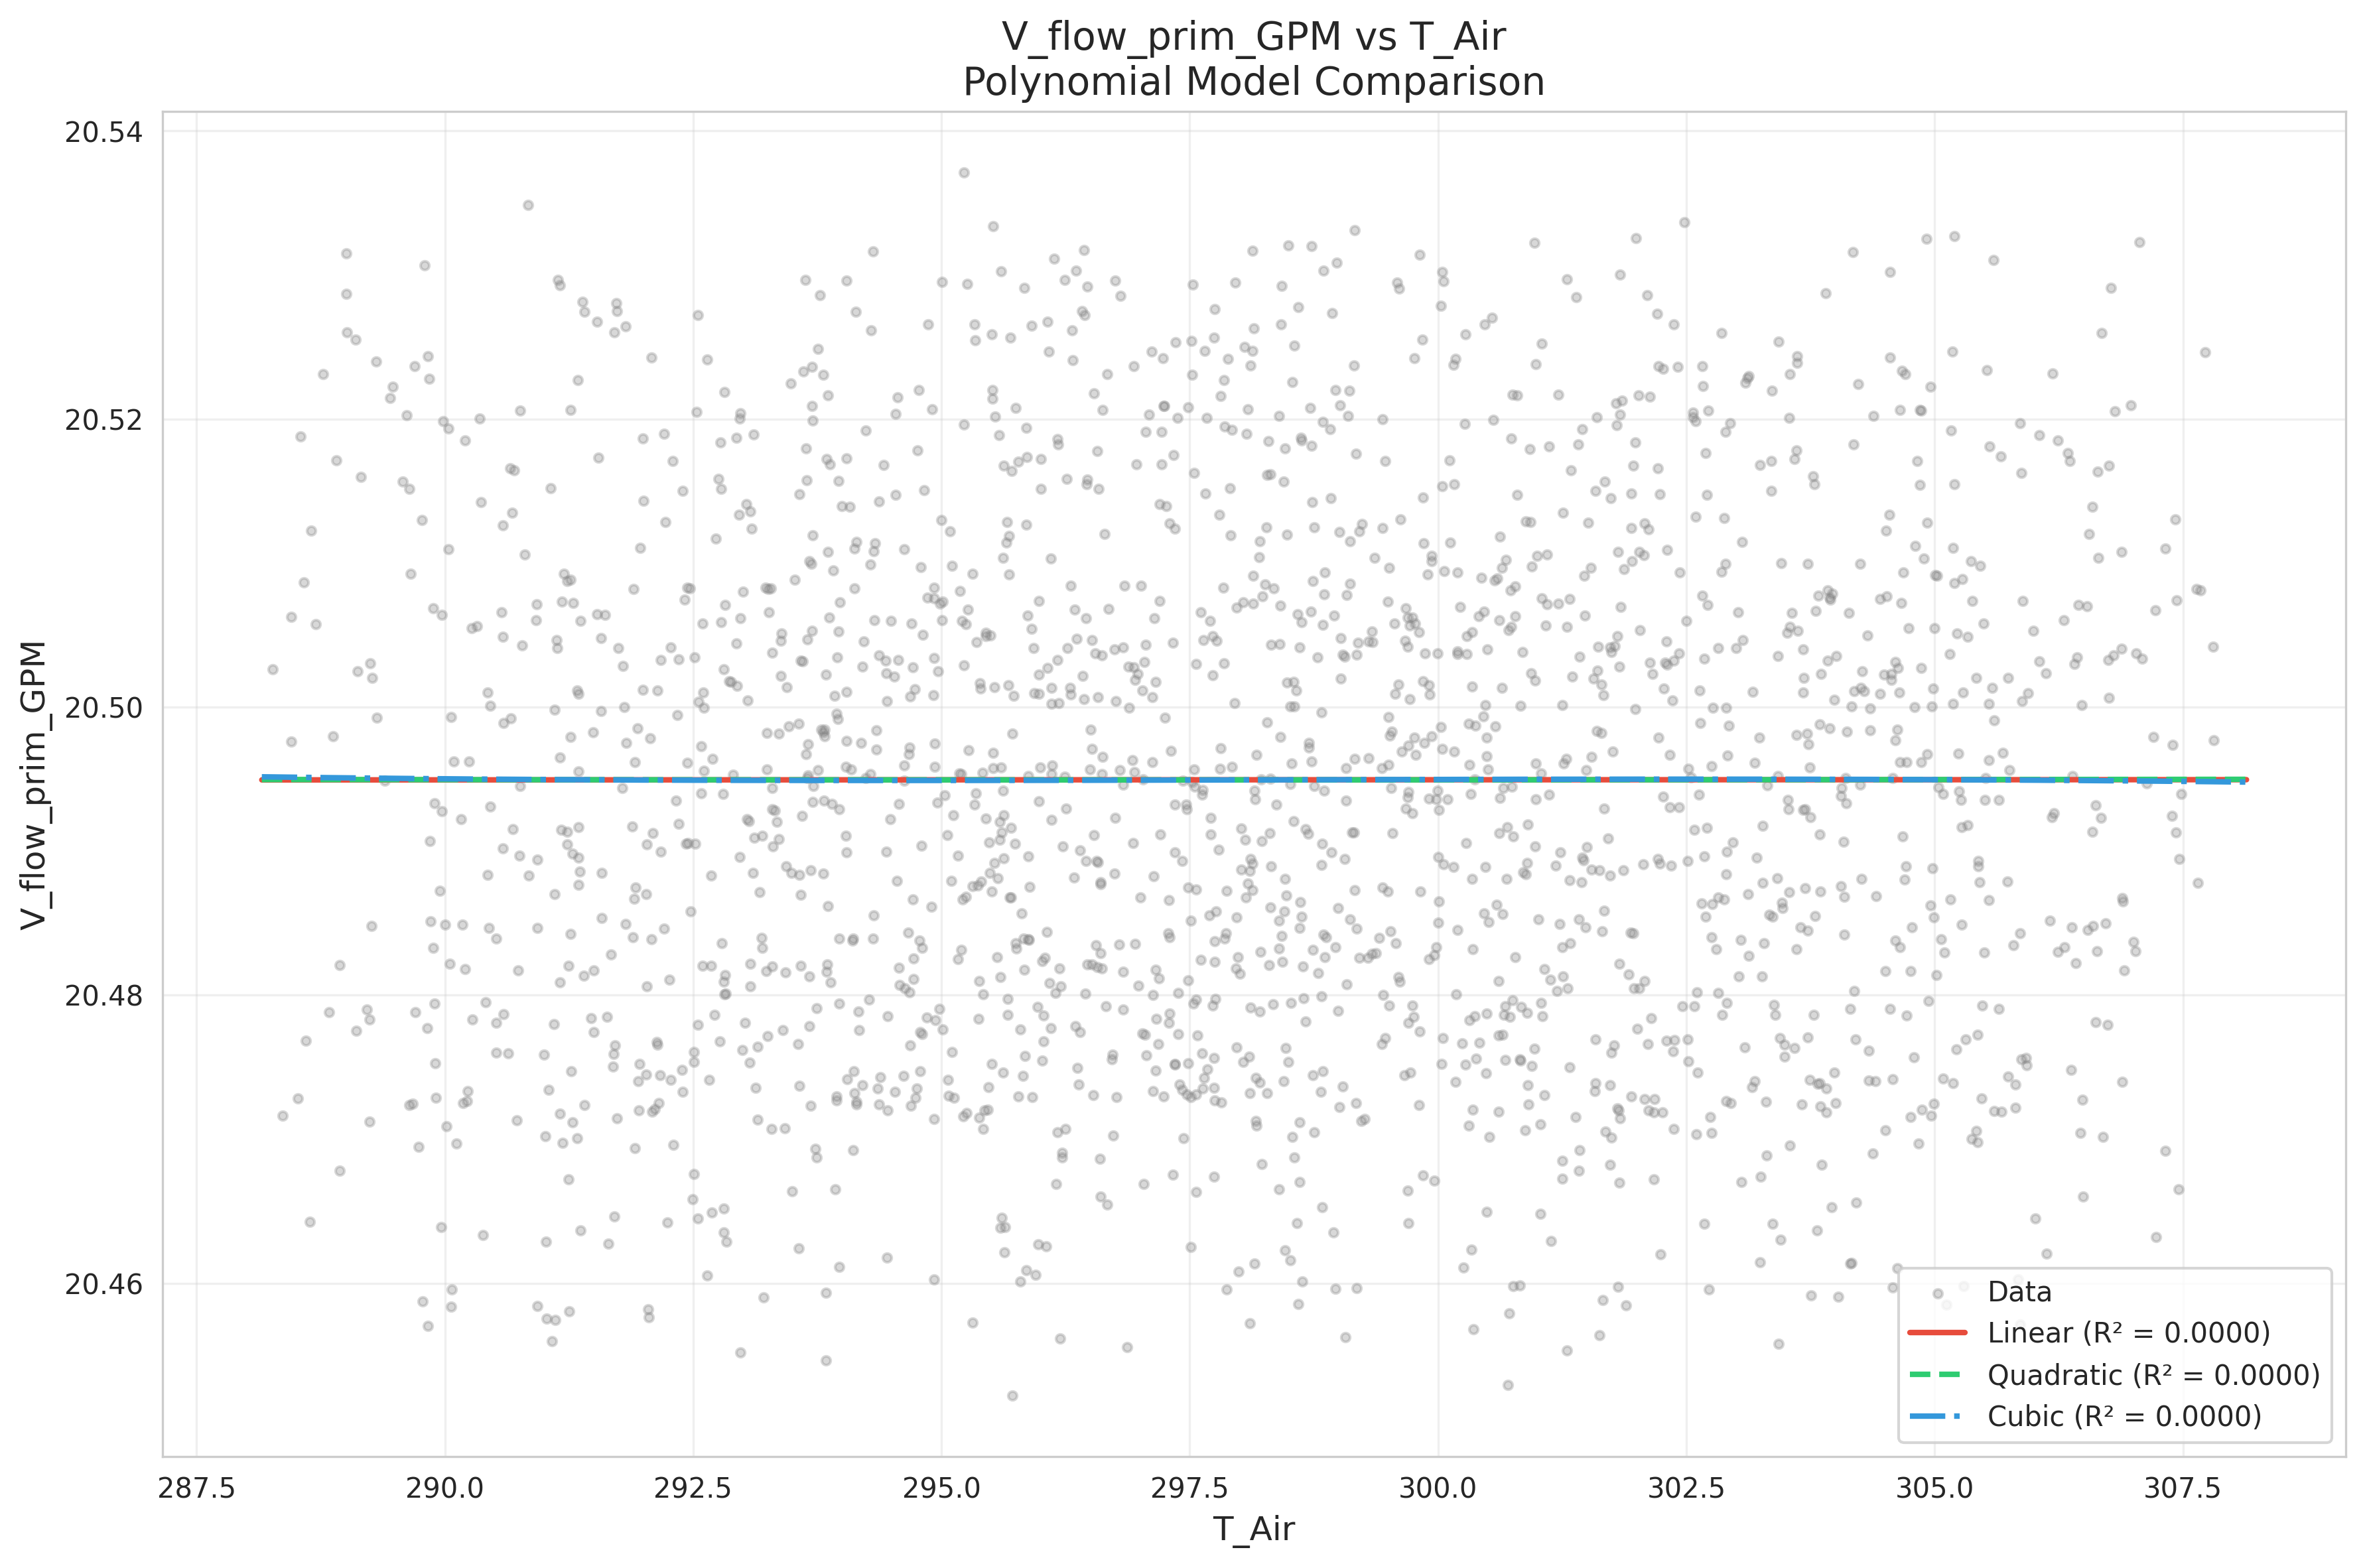

In [12]:
from IPython.display import Image

# Display example
poly_plots = [f for f in os.listdir(viz_dir) if f.startswith('nonlinearity_')]
Image(filename=os.path.join(viz_dir, poly_plots[3]))


2026-02-06 17:34:52 - fmu2ml.analysis.nonlinear_characterization.visualizers.model_comparison_visualizer - INFO - Creating model comparison plots...
2026-02-06 17:35:03 - fmu2ml.analysis.nonlinear_characterization.visualizers.model_comparison_visualizer - INFO - Created model comparison plots


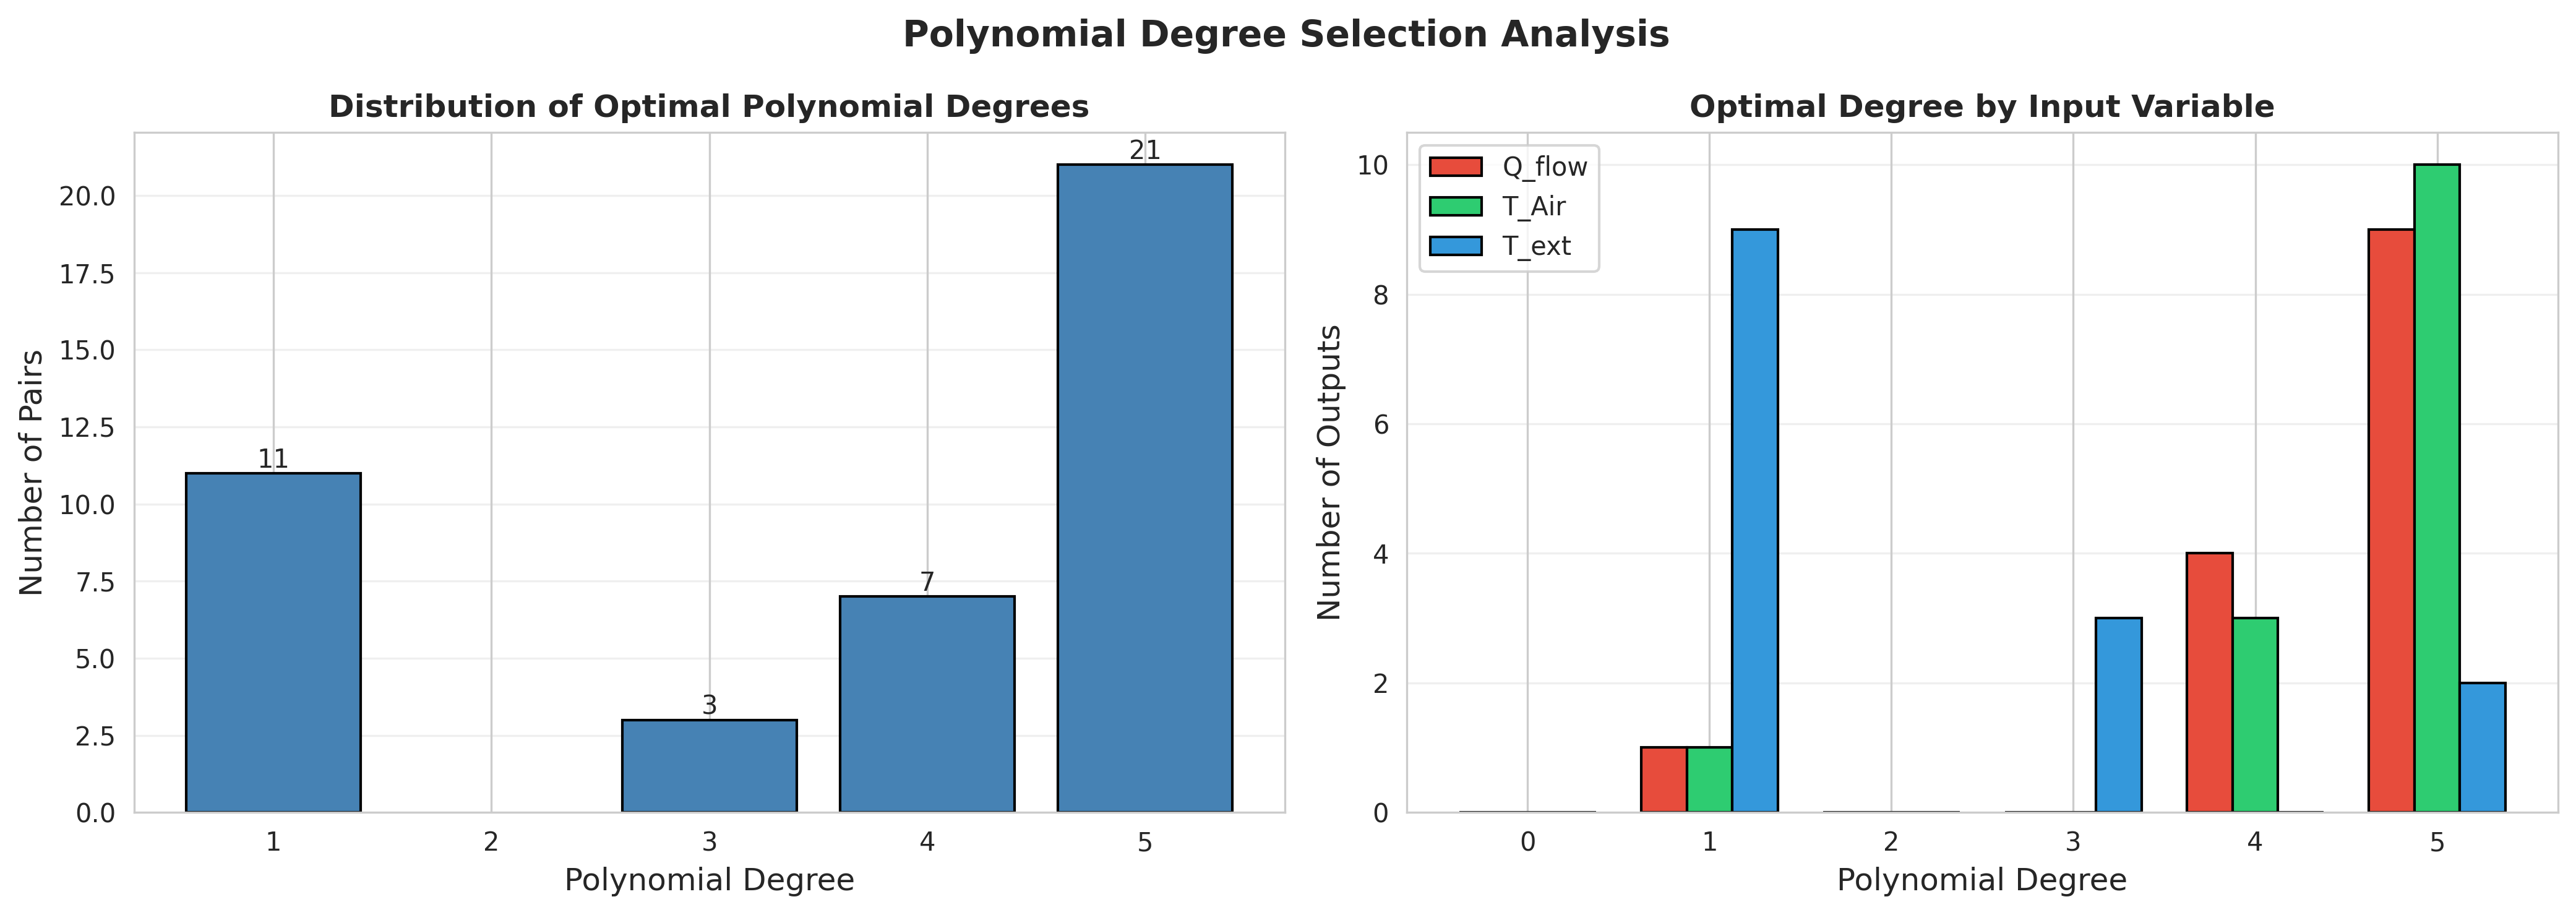

In [13]:

# Model Comparison Plots
create_model_comparison_plots(comparison_df, polynomial_df, viz_dir)
# Image(filename=os.path.join(viz_dir, 'r2_comparison_heatmap.png'))
# Image(filename=os.path.join(viz_dir, 'degree_r2_heatmap.png'))
Image(filename=os.path.join(viz_dir, 'best_degree_distribution.png'))

#

2026-02-06 17:35:03 - fmu2ml.analysis.nonlinear_characterization.visualizers.residual_visualizer - INFO - Creating residual plots in parallel...


Creating residual plots...


2026-02-06 17:35:09 - fmu2ml.analysis.nonlinear_characterization.visualizers.residual_visualizer - INFO - Created 9/9 residual plots
2026-02-06 17:35:09 - fmu2ml.analysis.nonlinear_characterization.visualizers.residual_visualizer - INFO - Creating residual summary plot...


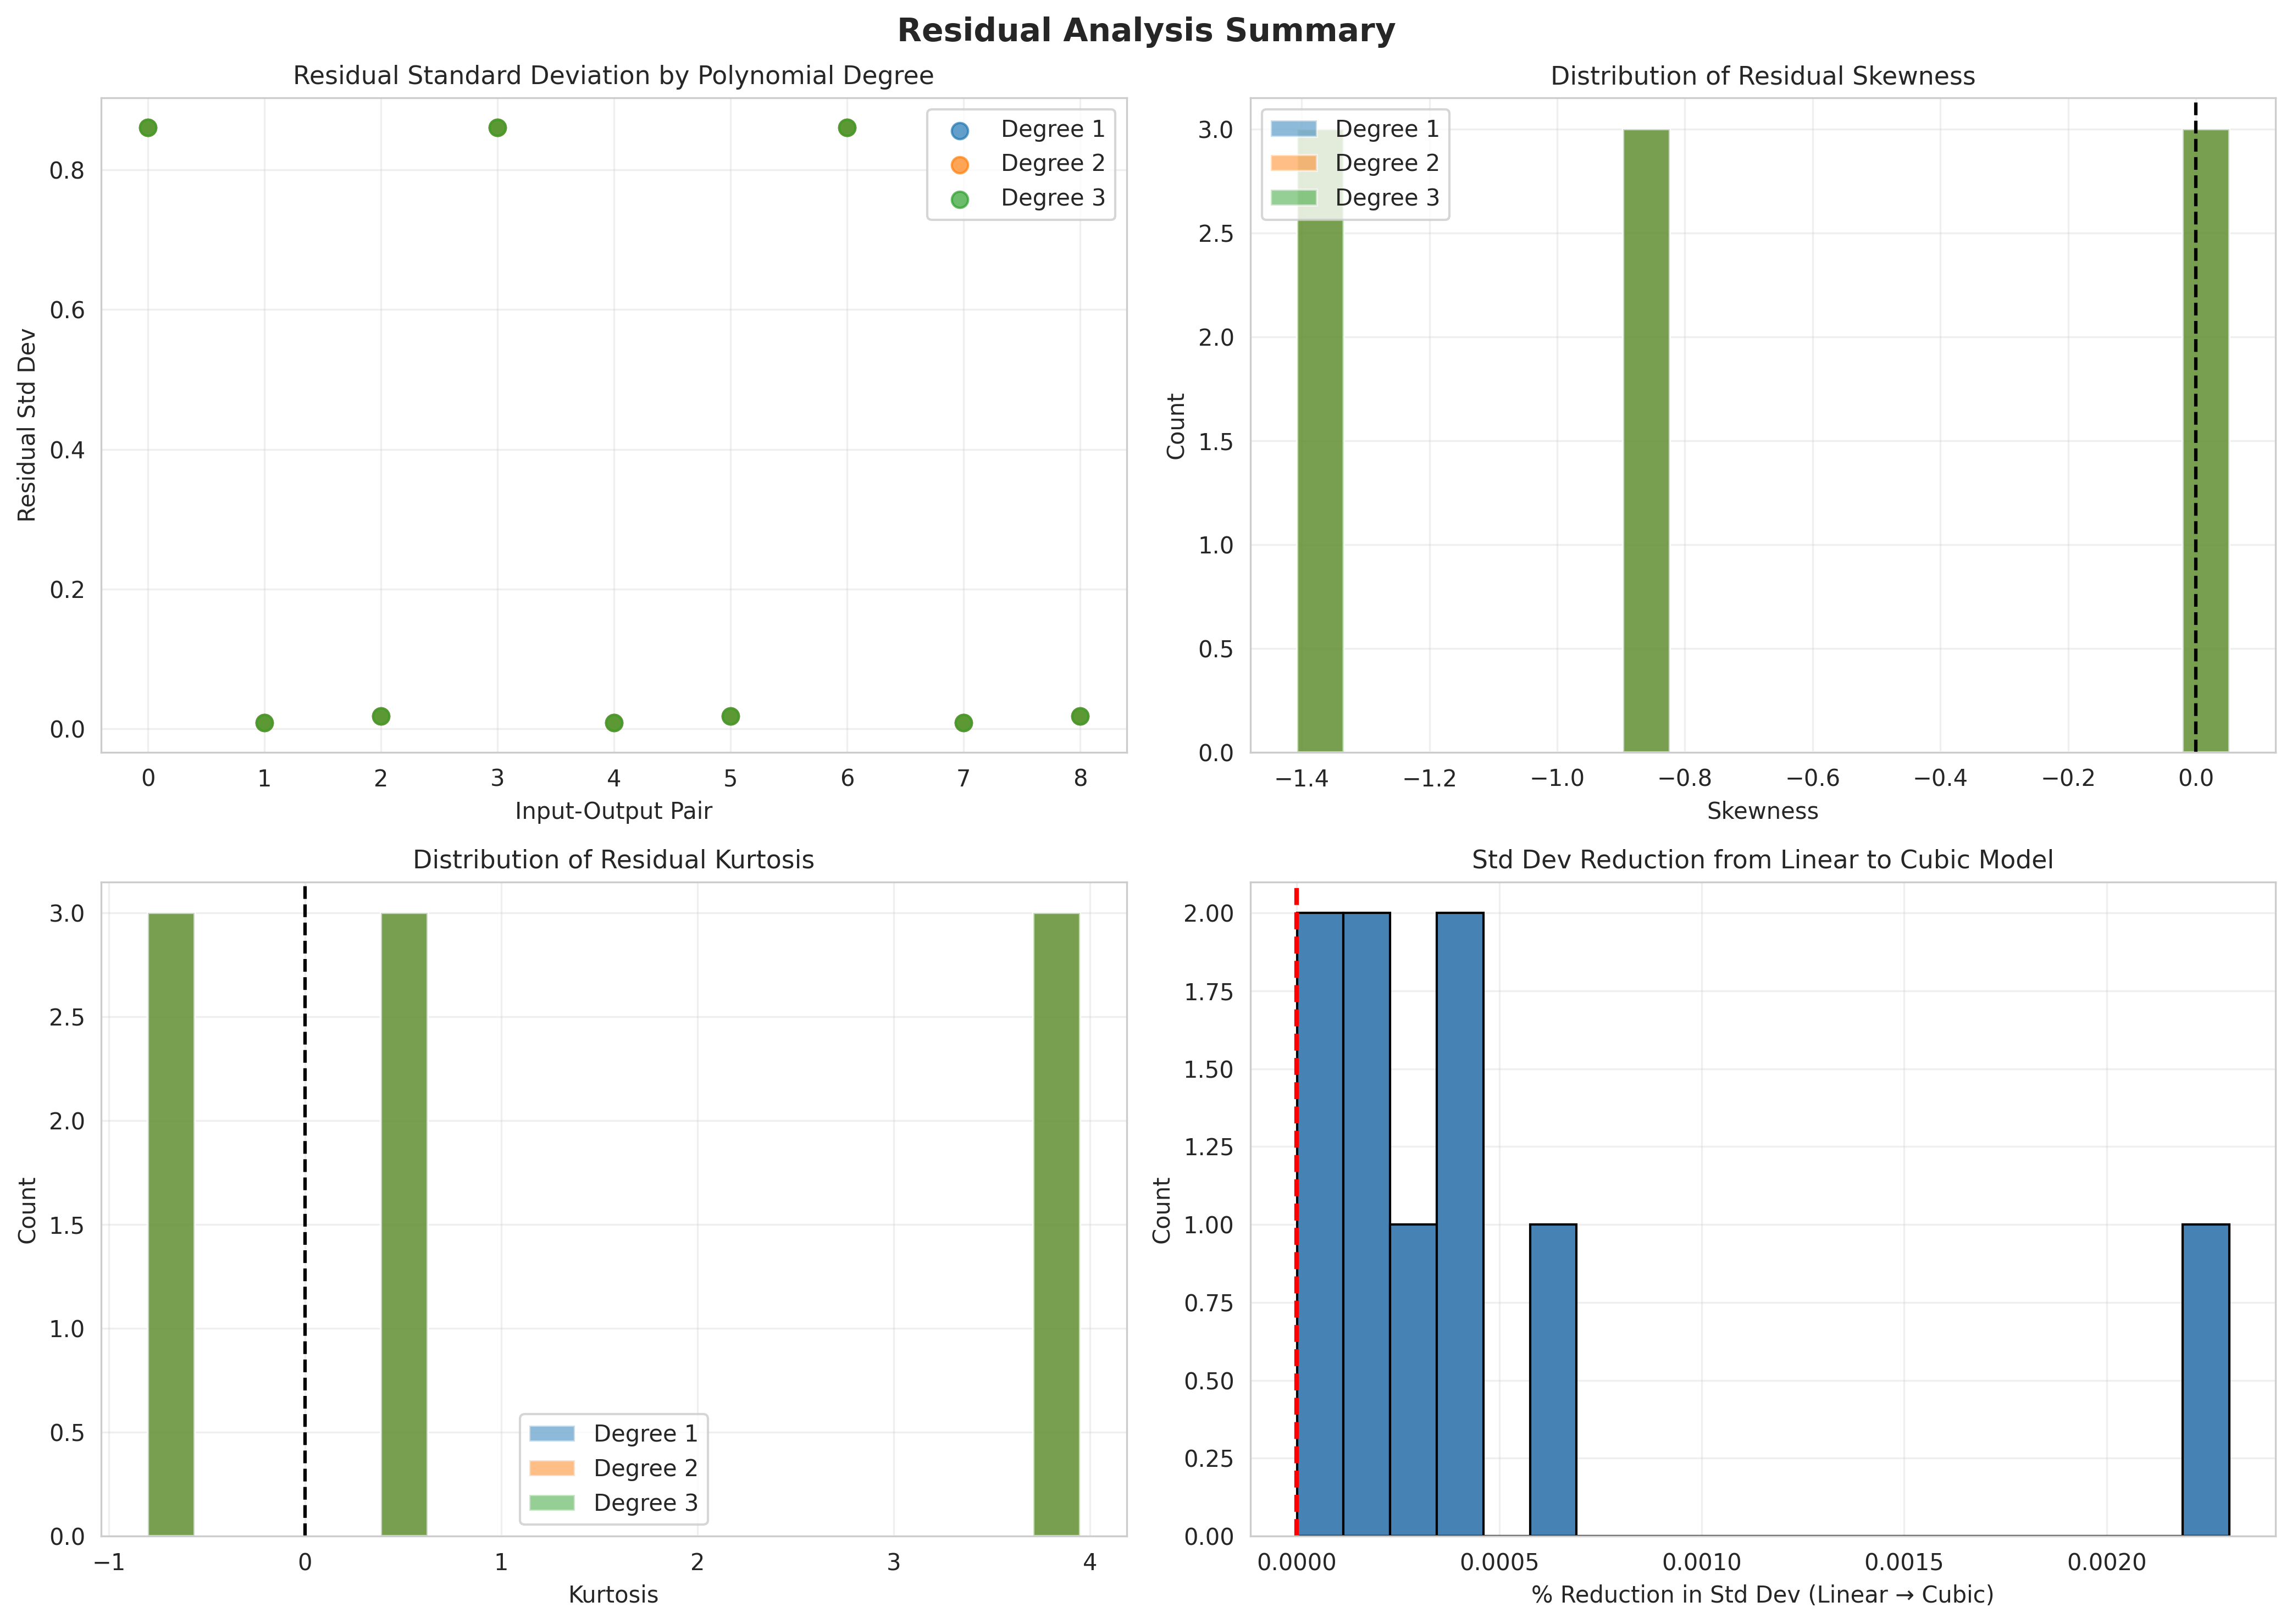

In [14]:
# Residual Analysis
residual_dir = os.path.join(OUTPUT_DIR, 'visualizations', 'residuals')
os.makedirs(residual_dir, exist_ok=True)

print("Creating residual plots...")
create_residual_plots(
    prediction_data_dict,
    residual_dir,
    n_workers=N_WORKERS
)

create_residual_summary_plot(prediction_data_dict, residual_dir)
Image(filename=os.path.join(residual_dir, 'residual_summary.png'))


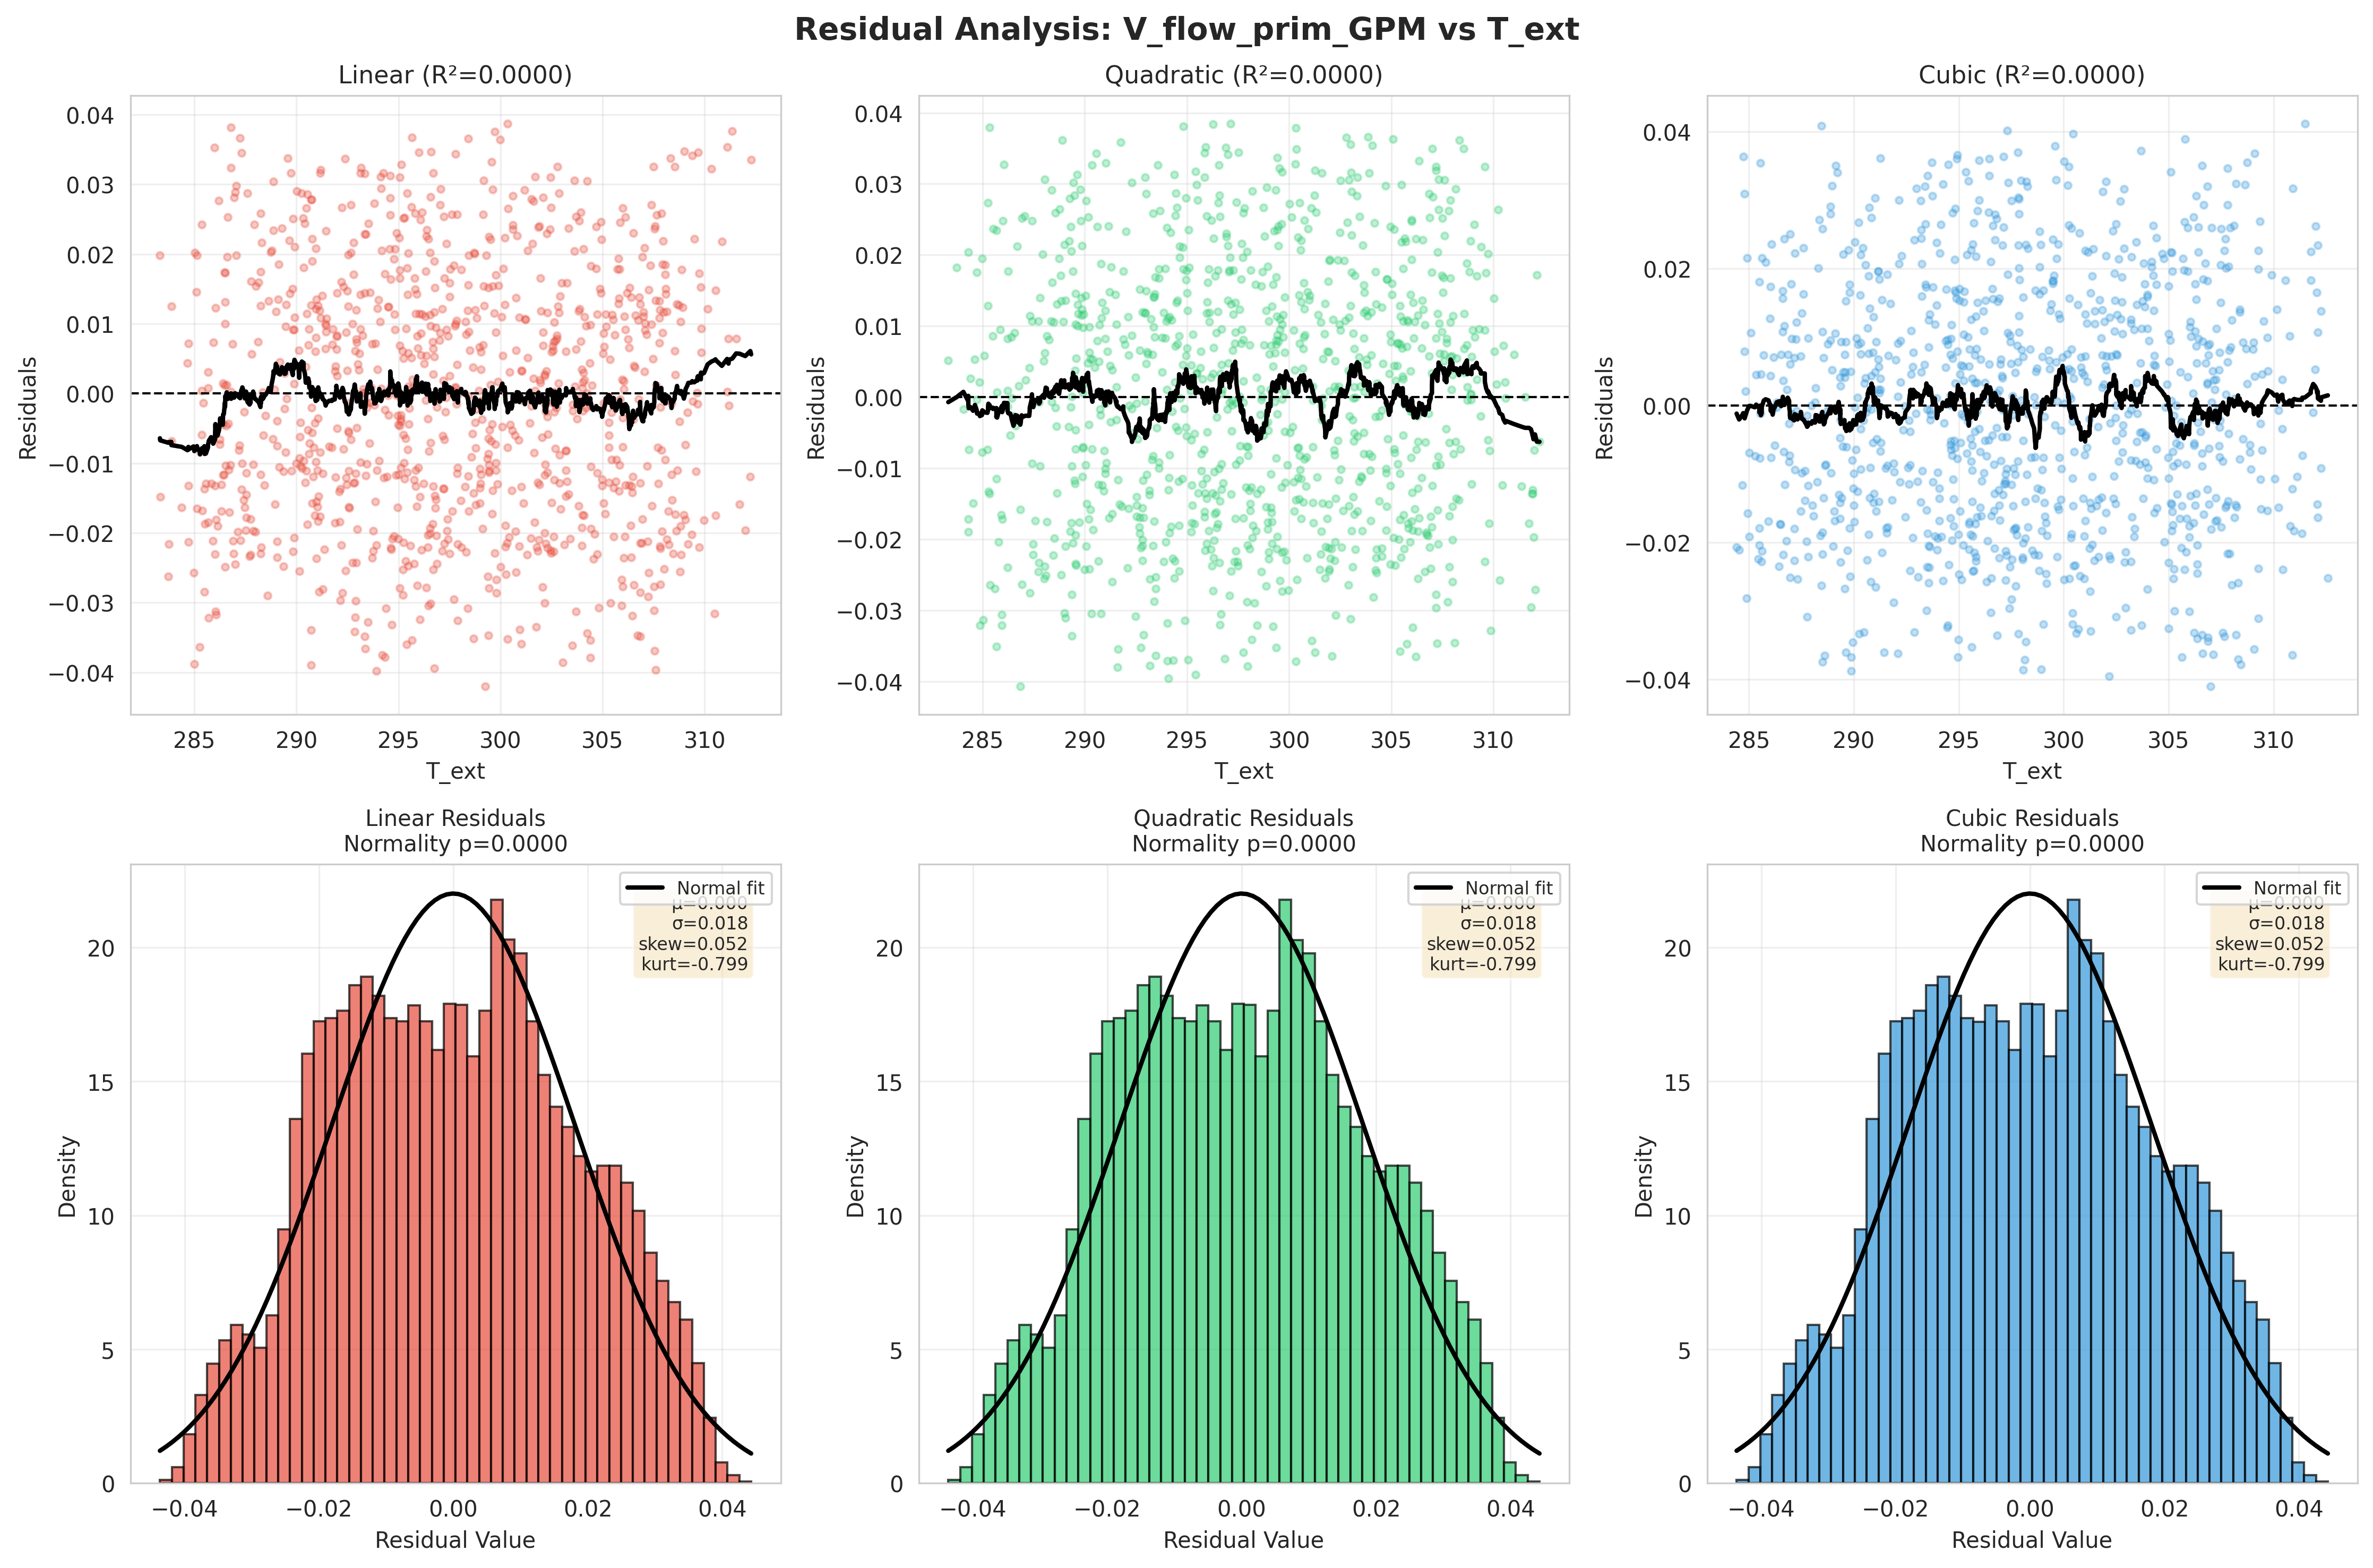

In [15]:
Image(filename=os.path.join(residual_dir, 'residuals_T_ext_V_flow_prim_GPM.png'))


## 2. Non-linearity Characterization Analysis

In [16]:
from fmu2ml.analysis.nonlinear_characterization.visualizers.strength_chart_visualizer import (
    create_neural_network_recommendations
)

2026-02-06 17:35:13 - fmu2ml.analysis.nonlinear_characterization.visualizers.strength_chart_visualizer - INFO - Creating non-linearity strength chart...
2026-02-06 17:35:13 - fmu2ml.analysis.nonlinear_characterization.visualizers.strength_chart_visualizer - WARNING - Maximum R² improvement is 253321.8 pp, which exceeds 100 pp. This suggests R² values were not properly clamped. Values will be capped at 100 pp for visualization.
2026-02-06 17:35:21 - fmu2ml.analysis.nonlinear_characterization.visualizers.strength_chart_visualizer - INFO - Debug R² summary: 0 pairs with negative linear R², 0 pairs with negative best nonlinear R²
2026-02-06 17:35:21 - fmu2ml.analysis.nonlinear_characterization.visualizers.strength_chart_visualizer - INFO - Created non-linearity strength charts
2026-02-06 17:35:21 - fmu2ml.analysis.nonlinear_characterization.visualizers.strength_chart_visualizer - INFO - Creating neural network recommendations...
2026-02-06 17:35:22 - fmu2ml.analysis.nonlinear_characterizat

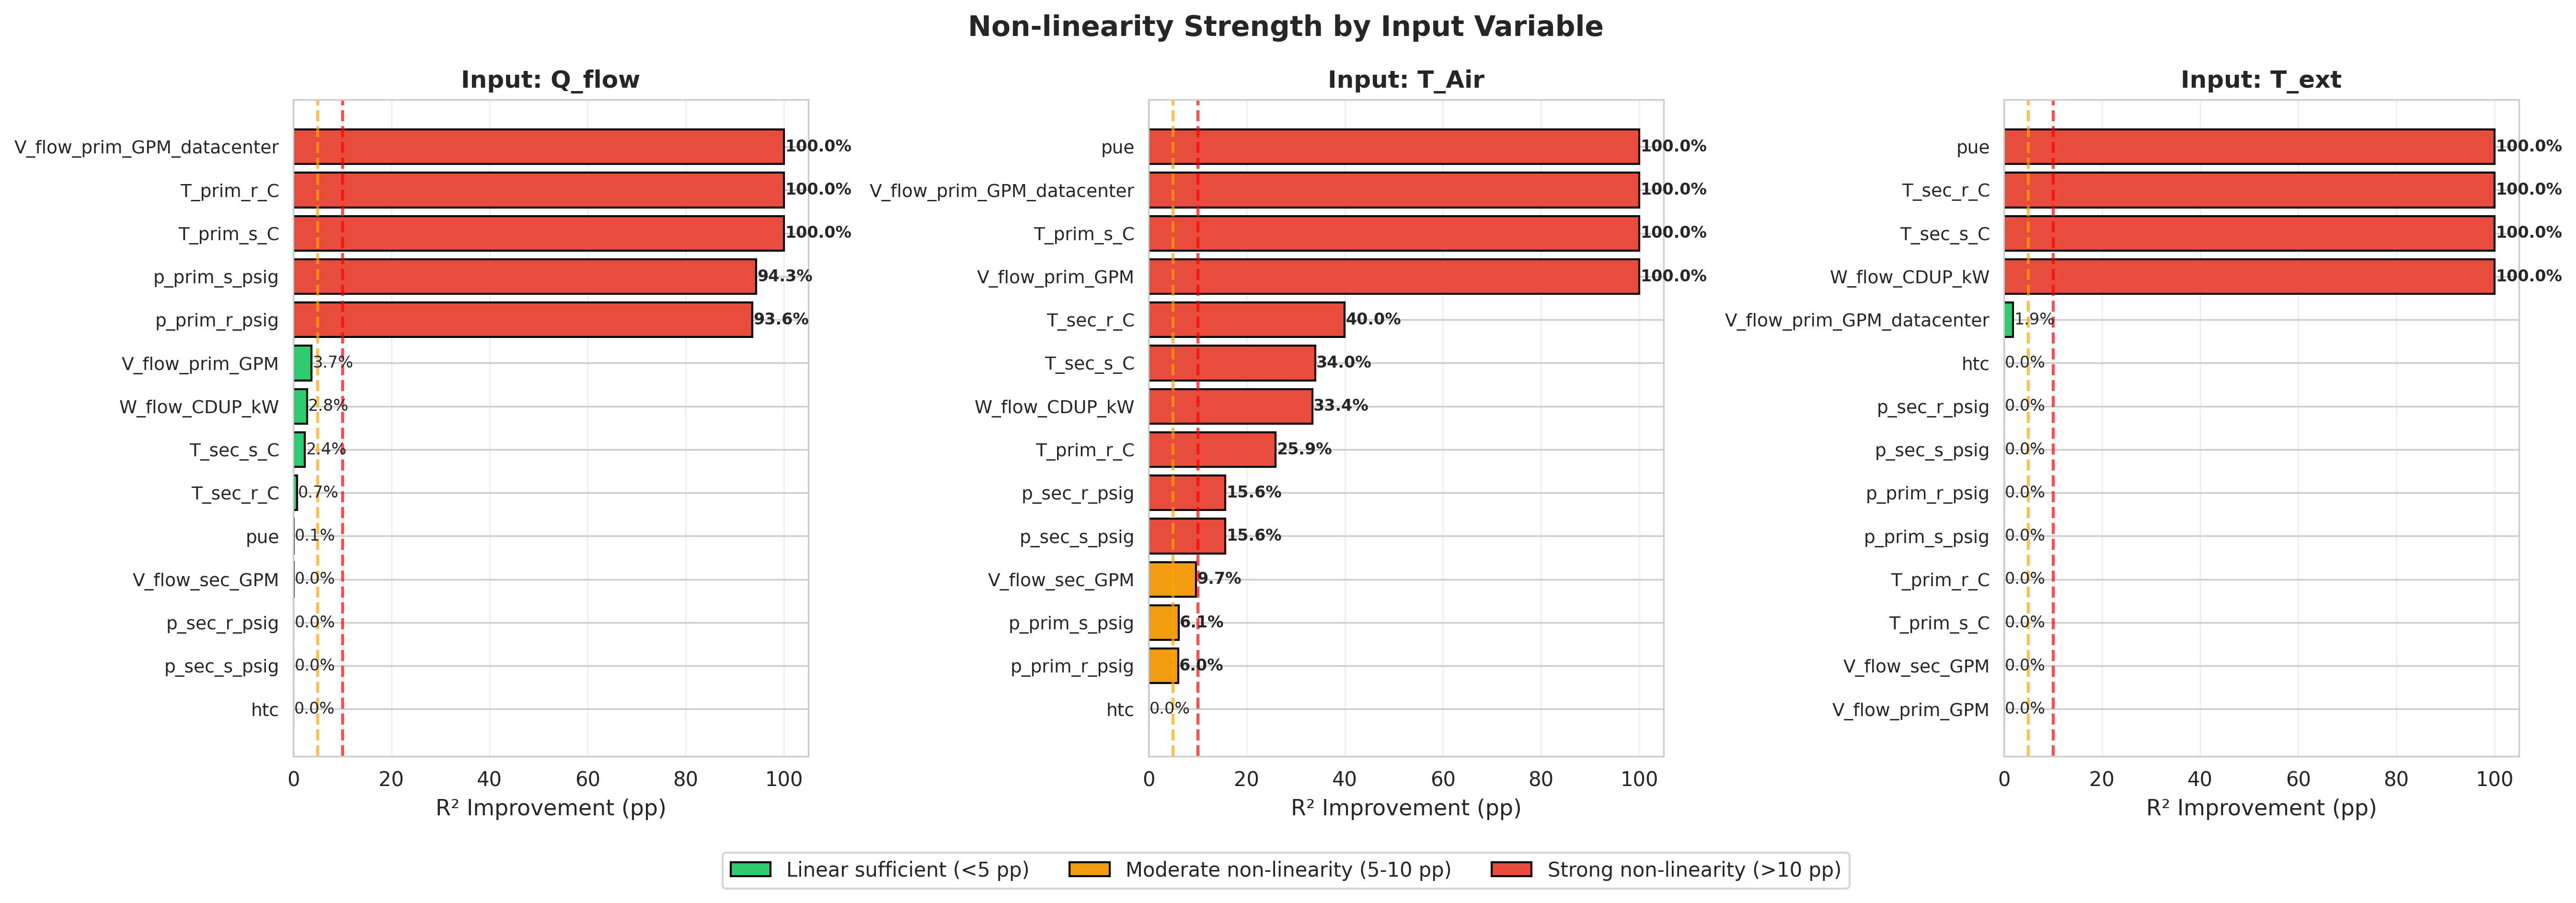

In [17]:

# Nonlinearity Strength Chart
strength_dir = os.path.join(OUTPUT_DIR, 'visualizations', 'nonlinearity_strength')
os.makedirs(strength_dir, exist_ok=True)

create_nonlinearity_strength_chart(comparison_df, strength_dir)
create_neural_network_recommendations(comparison_df, strength_dir)

Image(filename=os.path.join(strength_dir, 'nonlinearity_strength_by_input.png'))


In [19]:

#  Threshold Detection
print("Detecting thresholds and breakpoints...")
threshold_df, threshold_full_results = threshold_detector.detect_thresholds_all_pairs(prepared_data)

print(f"\nRelationships analyzed: {len(threshold_df)}")
print(f"Thresholds detected: {threshold_df['has_threshold'].sum()}")
print(f"Saturation detected: {threshold_df['has_saturation'].sum()}")

# Display threshold results
threshold_pairs = threshold_df[threshold_df['has_threshold']]
print(f"\nPairs with Thresholds ({len(threshold_pairs)}):")
threshold_pairs



2026-01-30 07:45:26 - fmu2ml.analysis.nonlinear_characterization.analyzers.threshold_detector - INFO - Detecting thresholds for all input-output pairs...
2026-01-30 07:45:26 - fmu2ml.analysis.nonlinear_characterization.analyzers.threshold_detector - INFO - Initializing Dask cluster for threshold detection...
2026-01-30 07:45:26 - distributed.scheduler - INFO - State start
2026-01-30 07:45:26 - distributed.scheduler - INFO -   Scheduler at:     tcp://127.0.0.1:40041
2026-01-30 07:45:26 - distributed.scheduler - INFO -   dashboard at:  http://127.0.0.1:33987/status
2026-01-30 07:45:26 - distributed.scheduler - INFO - Registering Worker plugin shuffle


Detecting thresholds and breakpoints...


2026-01-30 07:45:27 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:33723'
2026-01-30 07:45:27 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:39991'
2026-01-30 07:45:27 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:33255'
2026-01-30 07:45:27 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:39087'
2026-01-30 07:45:27 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:45109'
2026-01-30 07:45:27 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:37007'
2026-01-30 07:45:27 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:42247'
2026-01-30 07:45:27 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:45069'
2026-01-30 07:45:27 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:35795'
2026-01-30 07:45:27 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:41497'
2026-01-30 07:45:27 - distribu


Relationships analyzed: 42
Thresholds detected: 5
Saturation detected: 0

Pairs with Thresholds (5):


,input,output,n_breakpoints,linear_r2,segmented_r2,r2_improvement,has_threshold,has_saturation,regime_changes
12,Q_flow,V_flow_prim_GPM_datacenter,2,0.000230,0.011299,0.011069,True,False,True
26,T_Air,V_flow_prim_GPM_datacenter,2,0.013747,0.035930,0.022183,True,False,True
27,T_Air,pue,2,0.008594,0.024017,0.015423,True,False,True
40,T_ext,V_flow_prim_GPM_datacenter,2,0.484746,0.495417,0.010671,True,False,True
41,T_ext,pue,2,0.007453,0.026419,0.018966,True,False,True


2026-01-30 09:01:15 - distributed.core - INFO - Event loop was unresponsive in Nanny for 3.90s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
2026-01-30 09:01:15 - distributed.core - INFO - Event loop was unresponsive in Nanny for 3.90s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
2026-01-30 09:01:15 - distributed.core - INFO - Event loop was unresponsive in Nanny for 3.91s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
2026-01-30 09:01:15 - distributed.core - INFO - Event loop was unresponsive in Nanny for 3.91s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
2026-01-30 09:01:15 - distributed.core - INFO - Event loop was unresponsive in Nanny

In [20]:

# Threshold Details
# Analyze threshold characteristics
if not threshold_pairs.empty:
    print("\nThreshold Characteristics:")
    print(f"  Mean breakpoints: {threshold_pairs['n_breakpoints'].mean():.1f}")
    print(f"  Most common: {threshold_pairs['n_breakpoints'].mode()[0] if not threshold_pairs.empty else 'N/A'} breakpoints")
    
    
    print(f"  Mean R-square improvement: {threshold_pairs['r2_improvement'].mean():.2f}")

# Saturation analysis
saturation_pairs = threshold_df[threshold_df['has_saturation']]
if not saturation_pairs.empty:
    print(f"\nSaturation Behavior ({len(saturation_pairs)} pairs):")
    print(saturation_pairs[['input', 'output', 'n_breakpoints']])


Threshold Characteristics:
  Mean breakpoints: 2.0
  Most common: 2 breakpoints
  Mean R-square improvement: 0.02


In [21]:

#  Generate Segmented Fit Data
print("Generating segmented fit data for visualization...")
fit_data_dict = {}

for input_name in threshold_detector.input_vars:
    for output_name in KEY_OUTPUTS:
        if output_name in all_outputs:
            fit_data = threshold_detector.get_segmented_fit_data(
                prepared_data, input_name, output_name
            )
            if fit_data:
                fit_data_dict[(input_name, output_name)] = fit_data

print(f"Segmented fit data generated for {len(fit_data_dict)} pairs")


Generating segmented fit data for visualization...
Segmented fit data generated for 9 pairs


In [22]:

# Threshold Visualizations
threshold_viz_dir = os.path.join(OUTPUT_DIR, 'visualizations', 'thresholds')
os.makedirs(threshold_viz_dir, exist_ok=True)

print("Creating threshold visualizations...")
create_threshold_plots(
    fit_data_dict,
    threshold_viz_dir,
    n_workers=N_WORKERS
)

create_threshold_summary_plot(threshold_df, threshold_viz_dir)

# Display example
threshold_plots = [f for f in os.listdir(threshold_viz_dir) if f.startswith('threshold_')]
if threshold_plots:
    Image(filename=os.path.join(threshold_viz_dir, threshold_plots[0]))


2026-01-30 07:45:53 - fmu2ml.analysis.nonlinear_characterization.visualizers.threshold_visualizer - INFO - Creating threshold plots in parallel...


Creating threshold visualizations...


2026-01-30 07:45:56 - fmu2ml.analysis.nonlinear_characterization.visualizers.threshold_visualizer - INFO - Created 9/9 threshold plots
2026-01-30 07:45:56 - fmu2ml.analysis.nonlinear_characterization.visualizers.threshold_visualizer - INFO - Creating threshold summary plot...


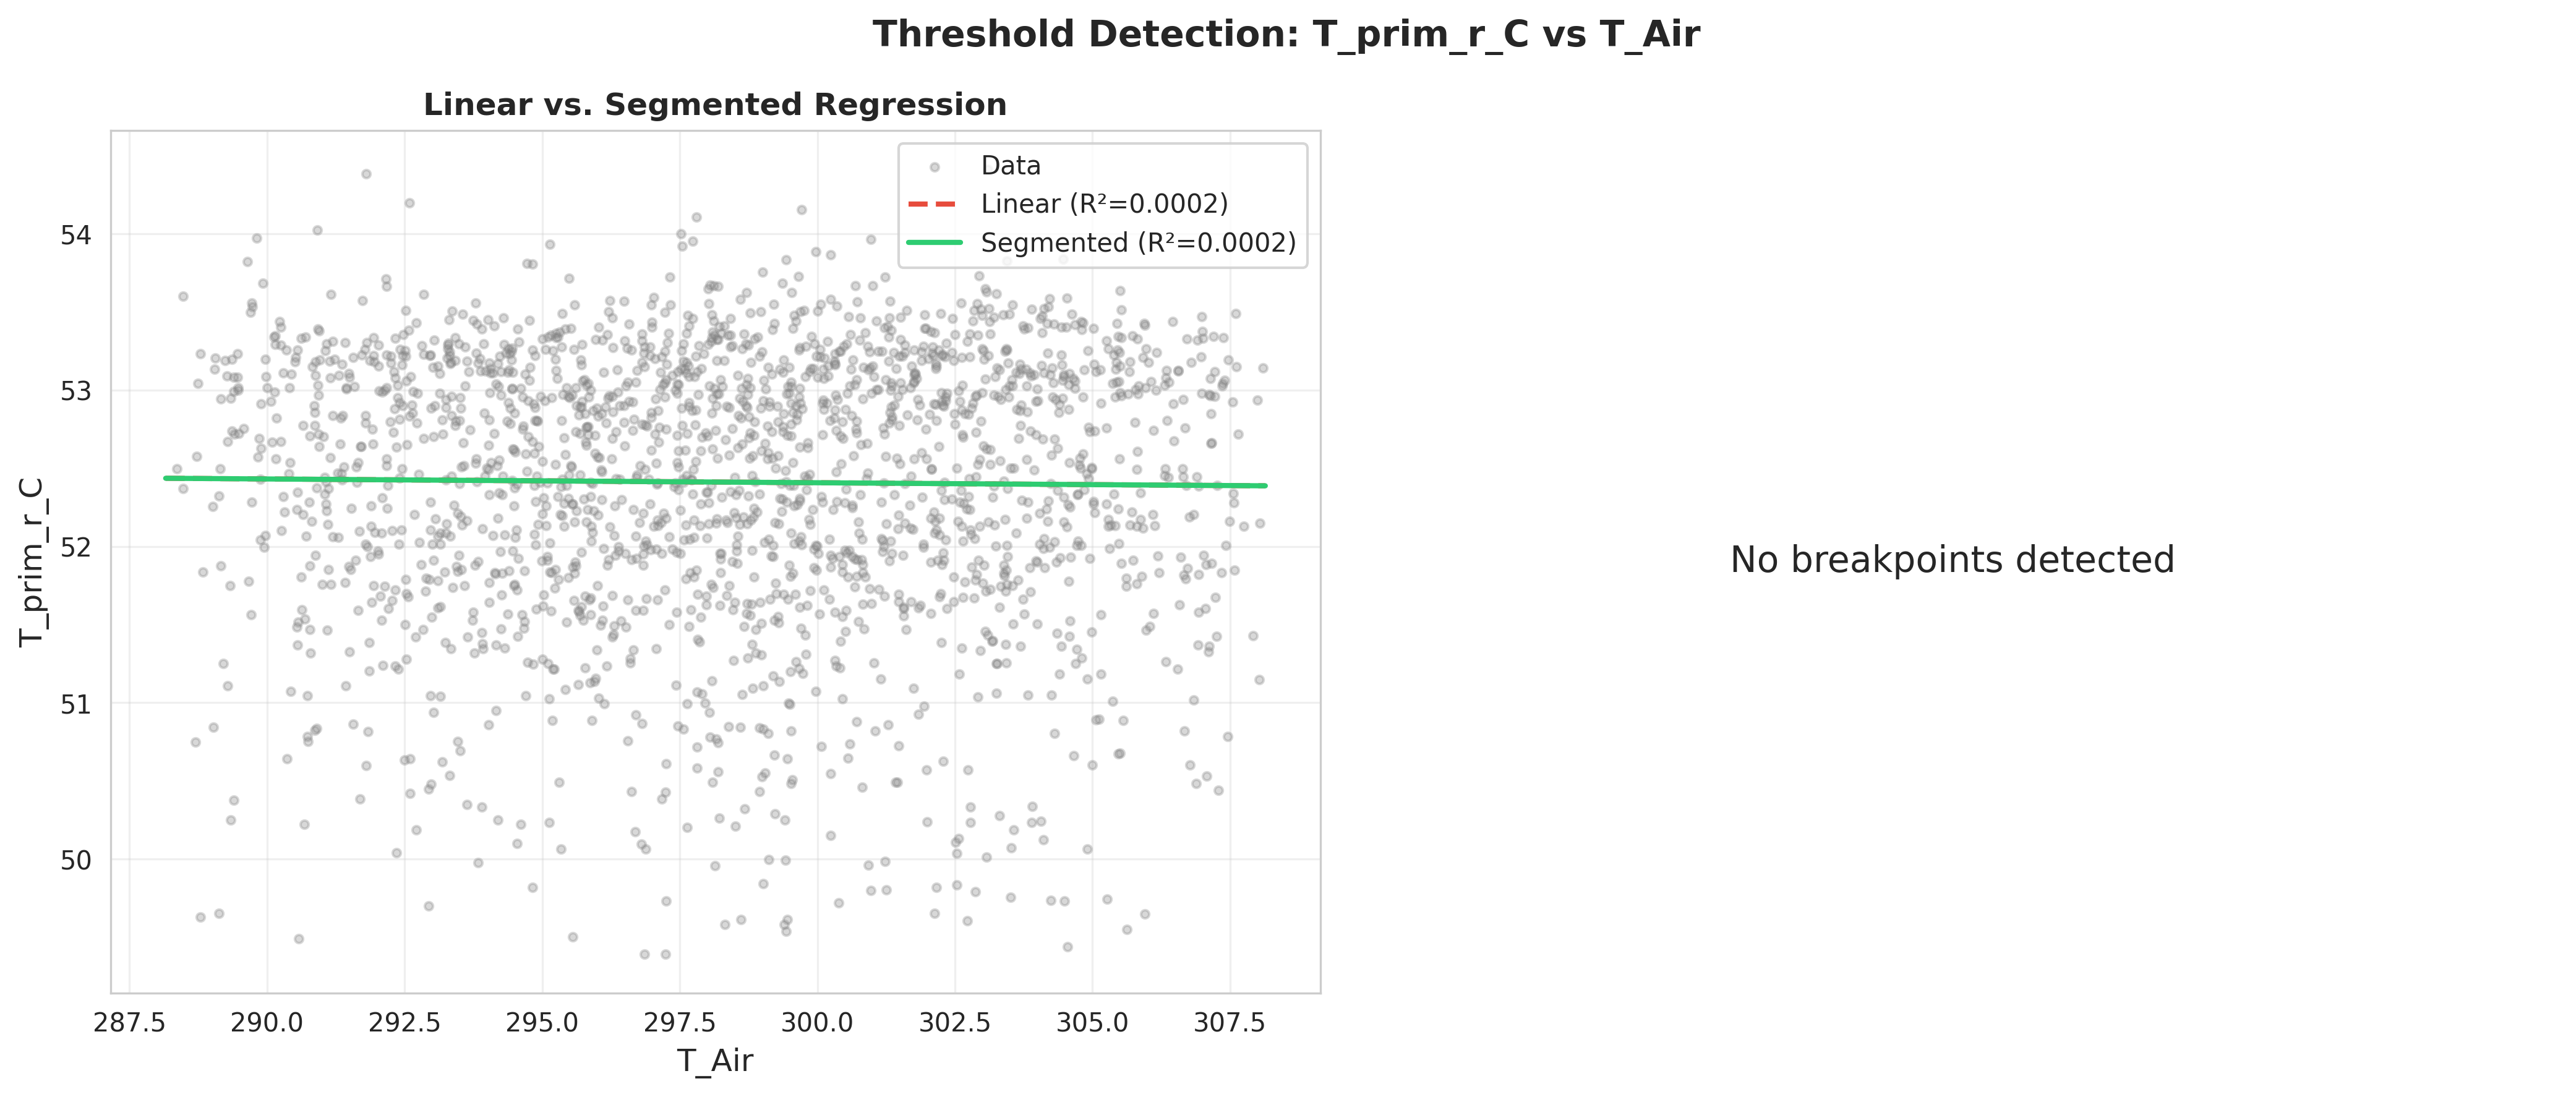

In [23]:
Image(filename=os.path.join(threshold_viz_dir, threshold_plots[1]))


## 3. Operating Regime Classification

In [7]:

# Operating Regime Classification
print("Classifying operating regimes...")
regime_df, regime_full_results = threshold_detector.classify_regimes_all_pairs(prepared_data)

print(f"\nRelationships analyzed: {len(regime_df)}")
print(f"Mean number of regimes: {regime_df['n_regimes'].mean():.1f}")

# Regime distribution
print("\nRegime Distribution:")
print(regime_df['n_regimes'].value_counts().sort_index())

# Multi-regime pairs
multi_regime = regime_df[regime_df['n_regimes'] > 2]
print(f"\nPairs with 3+ regimes: {len(multi_regime)}")
if not multi_regime.empty:
    print(multi_regime.nlargest(10, 'n_regimes')[['input', 'output', 'n_regimes']])


In [ ]:

# Regime Analysis Details
for input_var in ['Q_flow', 'T_Air', 'T_ext']:
    input_regimes = regime_df[regime_df['input'] == input_var]
    
    print(f"\n{input_var} Regime Analysis:")
    print(f"  Mean regimes: {input_regimes['n_regimes'].mean():.1f}")
    print(f"  Max regimes: {input_regimes['n_regimes'].max():.0f}")
    print(f"  Multi-regime pairs: {(input_regimes['n_regimes'] > 2).sum()}")


In [ ]:

# Regime Visualizations
regime_viz_dir = os.path.join(OUTPUT_DIR, 'visualizations', 'regimes')
os.makedirs(regime_viz_dir, exist_ok=True)

print("Creating regime visualizations...")
create_regime_scatter_plots(
    regime_full_results,
    regime_viz_dir,
    n_workers=N_WORKERS
)

# create_regime_summary_plot(regime_df, regime_viz_dir)

# Display example
regime_plots = [f for f in os.listdir(regime_viz_dir) if f.startswith('regime_')]
if regime_plots:
    Image(filename=os.path.join(regime_viz_dir, regime_plots[0]))


In [9]:


# Integrated Analysis - Nonlinearity Summary
print("="*60)
print("NONLINEARITY ANALYSIS SUMMARY")
print("="*60)

print(f"\nTotal Input-Output Pairs: {len(comparison_df)}")

# Overall nonlinearity
mean_improvement = comparison_df['r2_improvement_pct'].mean()
print(f"\nAverage R² Improvement: {mean_improvement:.2f}%")

# Categorize by improvement
weak = (comparison_df['r2_improvement_pct'] < 2).sum()
moderate = ((comparison_df['r2_improvement_pct'] >= 2) & 
            (comparison_df['r2_improvement_pct'] < 5)).sum()
strong = (comparison_df['r2_improvement_pct'] >= 5).sum()

print(f"\nNonlinearity Strength:")
print(f"  Weak (<2%): {weak} ({weak/len(comparison_df)*100:.1f}%)")
print(f"  Moderate (2-5%): {moderate} ({moderate/len(comparison_df)*100:.1f}%)")
print(f"  Strong (>5%): {strong} ({strong/len(comparison_df)*100:.1f}%)")

# Best polynomial degree distribution
print(f"\nOptimal Polynomial Degrees:")
for degree in sorted(comparison_df['best_degree'].unique()):
    count = (comparison_df['best_degree'] == degree).sum()
    print(f"  Degree {degree}: {count} ({count/len(comparison_df)*100:.1f}%)")


In [ ]:

# Integrated Analysis - Threshold Summary
print("="*60)
print("THRESHOLD & SATURATION SUMMARY")
print("="*60)

has_threshold = threshold_df['has_threshold'].sum()
has_saturation = threshold_df['has_saturation'].sum()

print(f"\nThreshold Detection:")
print(f"  With thresholds: {has_threshold} ({has_threshold/len(threshold_df)*100:.1f}%)")
print(f"  With saturation: {has_saturation} ({has_saturation/len(threshold_df)*100:.1f}%)")

if has_threshold > 0:
    threshold_subset = threshold_df[threshold_df['has_threshold']]
    print(f"\nThreshold Characteristics:")
    print(f"  Avg breakpoints: {threshold_subset['n_breakpoints'].mean():.1f}")
    print(f"  Most common: {threshold_subset['n_breakpoints'].mode()[0]} breakpoints")


In [ ]:

# Integrated Analysis - Regime Summary
print("="*60)
print("OPERATING REGIME SUMMARY")
print("="*60)

print(f"\nRegime Statistics:")
print(f"  Mean regimes per pair: {regime_df['n_regimes'].mean():.1f}")
print(f"  Median regimes: {regime_df['n_regimes'].median():.0f}")
print(f"  Max regimes: {regime_df['n_regimes'].max():.0f}")

print(f"\nComplex Behavior:")
print(f"  Pairs with 2 regimes: {(regime_df['n_regimes'] == 2).sum()}")
print(f"  Pairs with 3+ regimes: {(regime_df['n_regimes'] > 2).sum()}")


In [ ]:

# Save All Results
print("Saving results...")

# Save dataframes
comparison_df.to_csv(os.path.join(OUTPUT_DIR, 'model_comparison.csv'), index=False)
polynomial_df.to_csv(os.path.join(OUTPUT_DIR, 'polynomial_fits.csv'), index=False)
threshold_df.to_csv(os.path.join(OUTPUT_DIR, 'threshold_detection.csv'), index=False)
regime_df.to_csv(os.path.join(OUTPUT_DIR, 'regime_classification.csv'), index=False)

print(f"\nAll results saved to: {OUTPUT_DIR}")
print("\nFiles created:")
print("  - sensitivity_data.parquet")
print("  - model_comparison.csv")
print("  - polynomial_fits.csv")
print("  - threshold_detection.csv")
print("  - regime_classification.csv")
print("  - visualizations/polynomial/")
print("  - visualizations/residuals/")
print("  - visualizations/thresholds/")
print("  - visualizations/regimes/")
print("  - visualizations/nonlinearity_strength/")


In [18]:

# Cleanup
nonlinear_analyzer._close_dask_client()
threshold_detector._close_dask_client()

print("\nAnalysis complete! Dask clients closed.")

2026-02-06 17:35:49 - fmu2ml.analysis.nonlinear_characterization.analyzers.nonlinear_analyzer - INFO - Closing Dask cluster...
2026-02-06 17:35:49 - fmu2ml.analysis.nonlinear_characterization.analyzers.nonlinear_analyzer - INFO - Dask client closed



Analysis complete! Dask clients closed.
